<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/14_Long_Short_Term_Memory_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 14: Long Short Term Memory Networks

## Reproduksi dan Pendalaman Teori

Chapter ini membahas Long Short Term Memory (LSTM), sebuah pengembangan dari Recurrent Neural Network yang dirancang untuk mengatasi vanishing gradient dan meningkatkan kemampuan model dalam mempelajari dependensi jangka panjang.



# Learning Objectives

1. Memahami keterbatasan RNN biasa.
2. Memahami vanishing gradient.
3. Memahami konsep memory cell.
4. Memahami arsitektur LSTM.
5. Memahami forget gate.
6. Memahami input gate.
7. Memahami output gate.
8. Memahami cell state.
9. Mengimplementasikan LSTM sederhana menggunakan NumPy.
10. Memahami hubungan LSTM dengan NLP modern.



# Review Recurrent Neural Network

RNN menyimpan informasi masa lalu dalam hidden state.

Namun ketika urutan menjadi panjang, informasi lama sering hilang akibat propagasi gradien yang semakin kecil.



# Vanishing Gradient Problem

Saat error dipropagasikan ke banyak timestep, gradien dapat menjadi sangat kecil.

Akibatnya:

1. Informasi lama terlupakan.
2. Training menjadi sulit.
3. Dependensi jangka panjang gagal dipelajari.


In [1]:

import numpy as np

gradient = 1.0

for step in range(10):
    gradient *= 0.5
    print(step + 1, gradient)


1 0.5
2 0.25
3 0.125
4 0.0625
5 0.03125
6 0.015625
7 0.0078125
8 0.00390625
9 0.001953125
10 0.0009765625



# Ide Utama LSTM

LSTM memperkenalkan memory cell yang dapat menyimpan informasi penting dalam waktu yang lebih lama.

Komponen utama:

1. Cell State
2. Forget Gate
3. Input Gate
4. Output Gate



# Cell State

Cell state bertindak sebagai jalur memori utama.

Informasi dapat ditambahkan, dipertahankan, atau dihapus melalui mekanisme gate.



# Forget Gate

Forget gate menentukan informasi mana yang harus dipertahankan.

Nilai gate berada pada rentang 0 hingga 1.

0 berarti informasi dibuang.

1 berarti informasi dipertahankan sepenuhnya.


In [2]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.array([-2,-1,0,1,2])

print(sigmoid(x))


[0.11920292 0.26894142 0.5        0.73105858 0.88079708]



# Input Gate

Input gate menentukan informasi baru yang akan dimasukkan ke memory cell.



# Output Gate

Output gate menentukan bagian memory cell yang akan dikirim sebagai hidden state.



# Persamaan Dasar LSTM

Forget Gate:

f_t = sigmoid(Wf[h(t-1),x(t)])

Input Gate:

i_t = sigmoid(Wi[h(t-1),x(t)])

Candidate State:

g_t = tanh(Wg[h(t-1),x(t)])

Cell State:

C_t = f_t * C(t-1) + i_t * g_t

Output Gate:

o_t = sigmoid(Wo[h(t-1),x(t)])

Hidden State:

h_t = o_t * tanh(C_t)



# Visualisasi Alur Informasi

Input

→ Forget Gate

→ Input Gate

→ Cell State

→ Output Gate

→ Hidden State

Arsitektur ini memungkinkan informasi penting bertahan lebih lama dibandingkan RNN biasa.


In [3]:

def tanh(x):
    return np.tanh(x)

print(tanh(np.array([-2,-1,0,1,2])))


[-0.96402758 -0.76159416  0.          0.76159416  0.96402758]



# Implementasi Komponen LSTM Menggunakan NumPy


In [4]:

import numpy as np

input_size = 3
hidden_size = 4

Wf = np.random.randn(
    input_size + hidden_size,
    hidden_size
) * 0.1

Wi = np.random.randn(
    input_size + hidden_size,
    hidden_size
) * 0.1

Wo = np.random.randn(
    input_size + hidden_size,
    hidden_size
) * 0.1

Wg = np.random.randn(
    input_size + hidden_size,
    hidden_size
) * 0.1



# Forward Pass LSTM Cell


In [5]:

def lstm_step(x, h_prev, c_prev):

    combined = np.concatenate(
        [x, h_prev]
    )

    f = sigmoid(
        np.dot(combined, Wf)
    )

    i = sigmoid(
        np.dot(combined, Wi)
    )

    o = sigmoid(
        np.dot(combined, Wo)
    )

    g = np.tanh(
        np.dot(combined, Wg)
    )

    c = f * c_prev + i * g

    h = o * np.tanh(c)

    return h, c


In [6]:

x = np.array([1.0,0.5,0.2])

h = np.zeros(hidden_size)

c = np.zeros(hidden_size)

h, c = lstm_step(x,h,c)

print("Hidden State")
print(h)

print()

print("Cell State")
print(c)


Hidden State
[-0.03748416  0.02909045 -0.00717798 -0.02072353]

Cell State
[-0.07453525  0.06426676 -0.01416768 -0.04120943]



# Memproses Sequence Menggunakan LSTM


In [7]:

sequence = [
    np.array([1.0,0.5,0.2]),
    np.array([0.8,0.2,0.4]),
    np.array([0.4,0.7,0.3]),
    np.array([0.6,0.9,0.1])
]

h = np.zeros(hidden_size)
c = np.zeros(hidden_size)

outputs = []

for x in sequence:

    h, c = lstm_step(
        x,
        h,
        c
    )

    outputs.append(h)

outputs


[array([-0.03748416,  0.02909045, -0.00717798, -0.02072353]),
 array([-0.05773523,  0.03664739, -0.01387444, -0.02894625]),
 array([-0.07423846,  0.05195523, -0.0202246 , -0.06151481]),
 array([-0.08236668,  0.06003552, -0.02056216, -0.07704439])]


# Visualisasi Evolusi Hidden State


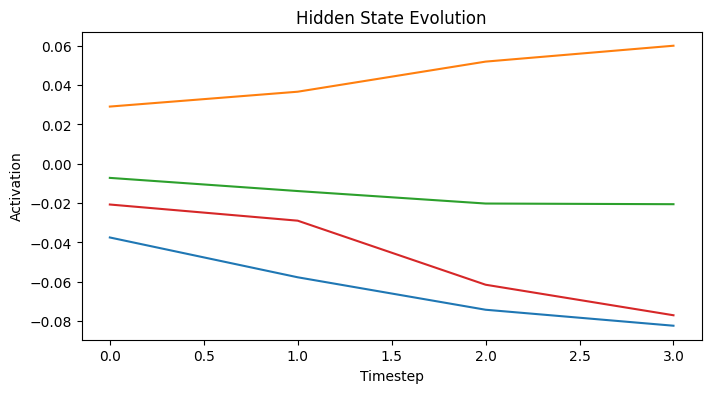

In [8]:

import matplotlib.pyplot as plt

outputs = np.array(outputs)

plt.figure(figsize=(8,4))

for i in range(outputs.shape[1]):
    plt.plot(outputs[:,i])

plt.title("Hidden State Evolution")
plt.xlabel("Timestep")
plt.ylabel("Activation")

plt.show()



# Perbandingan RNN dan LSTM

RNN:

1. Struktur sederhana.
2. Training lebih cepat.
3. Sulit menyimpan informasi jangka panjang.

LSTM:

1. Lebih kompleks.
2. Lebih banyak parameter.
3. Mampu mempelajari dependensi panjang.



# Aplikasi LSTM

1. Language Modeling
2. Sentiment Analysis
3. Machine Translation
4. Speech Recognition
5. Time Series Forecasting
6. Healthcare Analytics



# Many to One Classification

Contoh:

Kalimat → Sentimen

LSTM membaca seluruh urutan dan menghasilkan satu output klasifikasi.



# Many to Many Prediction

Contoh:

Machine Translation

Bahasa sumber dipetakan menjadi bahasa target.



# Hubungan dengan Word Embedding

Pada NLP modern, input LSTM biasanya berasal dari embedding layer.

Embedding menyediakan representasi semantik kata sebelum diproses oleh LSTM.



# Bidirectional LSTM

Bidirectional LSTM membaca urutan dari:

1. Kiri ke kanan.
2. Kanan ke kiri.

Hal ini memungkinkan model memperoleh konteks dari kedua arah.



# Hubungan dengan GRU

GRU merupakan penyederhanaan LSTM.

GRU memiliki:

1. Update Gate
2. Reset Gate

Jumlah parameter lebih sedikit dibandingkan LSTM.



# Hubungan dengan Attention

Meskipun LSTM sangat sukses, model modern mulai menggunakan attention mechanism untuk menangani dependensi panjang secara lebih efektif.



# Hubungan dengan Transformer

Transformer menggantikan pemrosesan berurutan menggunakan self attention.

Namun pemahaman LSTM tetap penting karena menjadi fondasi perkembangan NLP modern.



# Kelebihan LSTM

1. Mengurangi vanishing gradient.
2. Menyimpan informasi lebih lama.
3. Cocok untuk data sekuensial.
4. Performa kuat pada banyak tugas NLP.



# Keterbatasan LSTM

1. Training lebih lambat.
2. Parameter lebih banyak.
3. Sulit diparalelkan.
4. Mulai tergeser oleh Transformer.



# Latihan

1. Implementasikan Bidirectional LSTM sederhana.
2. Tambahkan embedding layer.
3. Visualisasikan cell state.
4. Bandingkan output RNN dan LSTM.
5. Implementasikan sentiment analysis sederhana.



# Kesimpulan

Pada chapter ini kita mempelajari:

1. Vanishing Gradient.
2. Memory Cell.
3. Forget Gate.
4. Input Gate.
5. Output Gate.
6. Cell State.
7. Hidden State.
8. Forward Pass LSTM.
9. Implementasi NumPy dari Nol.
10. Hubungan LSTM dengan NLP modern.

LSTM merupakan salah satu inovasi terpenting dalam deep learning karena memungkinkan neural network mempelajari informasi jangka panjang yang sulit ditangani oleh RNN tradisional.
